# Availability and activity in the London Airbnb calendar

**The data:** From Kaggle, Inside Airbnb London, scraped 5–6 November 2019. For every listing and each date of the following year, the calendar says whether that date is open for booking.

**Goal:** This notebook backs two choices in the study, [notebook 02](02-pricing-behavior.ipynb):
* which listings count as active;
* why an unavailable date is never treated as a booked one.

**Honesty Frame:** The calendar can't tell a booked night from a blocked one. So runs of unavailable dates are called unavailability spells, and the notebook gives no bookings, occupancy or revenue numbers. Results carry one of two labels:
* observed: read directly from the data;
* derived (rule-based): a stated rule applied to observed values.



In [1]:
import sys
sys.path.append("..")

import json
import matplotlib.pyplot as plt
import pandas as pd
from src.data import DATA_DIR, load_listings
from src.calendar_panel import load_calendar_slim
from src.definitions import is_active

import math
from matplotlib.colors import LinearSegmentedColormap, Normalize

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

listings = load_listings()
cal = load_calendar_slim()[["listing_id", "date", "available"]]
print(f"{len(listings):,} listings | {len(cal):,} listing-dates")


85,068 listings | 31,050,094 listing-dates


## 1. Calendar coverage
We check that every listing has a calendar, and which dates each calendar covers.

In [2]:
per_listing = cal.groupby("listing_id").agg(
    first_date=("date", "min"),
    last_date=("date", "max"),
    n_days=("date", "size"),
    n_available=("available", "sum"),
)
assert set(per_listing.index) == set(listings["id"]), "listings and calendar don't match"

span = (per_listing["last_date"] - per_listing["first_date"]).dt.days + 1
assert (span == per_listing["n_days"]).all(), "a calendar has missing days"

coverage = per_listing.groupby(["first_date", "last_date", "n_days"]).size().rename("listings")
print(coverage)



first_date  last_date   n_days
2019-11-05  2020-11-03  365       25961
            2020-11-04  366         274
2019-11-06  2020-11-04  365       58833
Name: listings, dtype: int64


**What section 1 shows**:
* **Two scrape days**: 26,235 listings were scraped on 5 November and 58,833 on 6 November.
* **One year per listing**: each calendar covers the year starting on that listing's own first date. 274 calendars run one day longer: 366 days, to 4 November 2020.
* **Why it matters**: the study sets each listing's window by its own first and last dates, never by a fixed 365 days. 

## 2. Which listings count as active?
* **The question**: about a third of listings never show a single open date in the year ahead. Does that mean they're out of the market?
* **Two signals**:
    - *availability*: the calendar shows at least one open date;
    - *review recency*: the listing got a review in the 12 months before the scrape.
* **The rule**: the study's is_active counts a listing as active if either signal is on. This section shows why neither signal alone is enough.


In [3]:
per_listing["no_open_date"] = per_listing["n_available"].eq(0)
per_listing["unavailable_365"] = (per_listing["n_days"] - per_listing["n_available"]).eq(365)

n_none = per_listing["no_open_date"].sum()
print(f"No open date: {n_none:,} of {len(per_listing):,} listings ({n_none / len(per_listing):.1%})")

check = per_listing.groupby("n_days")[["no_open_date", "unavailable_365"]].sum()
check.loc["all"] = check.sum()
print(check)


No open date: 28,095 of 85,068 listings (33.0%)
        no_open_date  unavailable_365
n_days                               
365            27835            27835
366              260                2
all            28095            27837


             listings  share %
n_available                   
none            28095     33.0
1–30             8552     10.1
31–60            6026      7.1
61–90            7277      8.6
91–120           2681      3.2
121–150          3416      4.0
151–180          4712      5.5
181–210          1123      1.3
211–240          1535      1.8
241–270          1956      2.3
271–300          2493      2.9
301–330          5246      6.2
331–366         11956     14.1


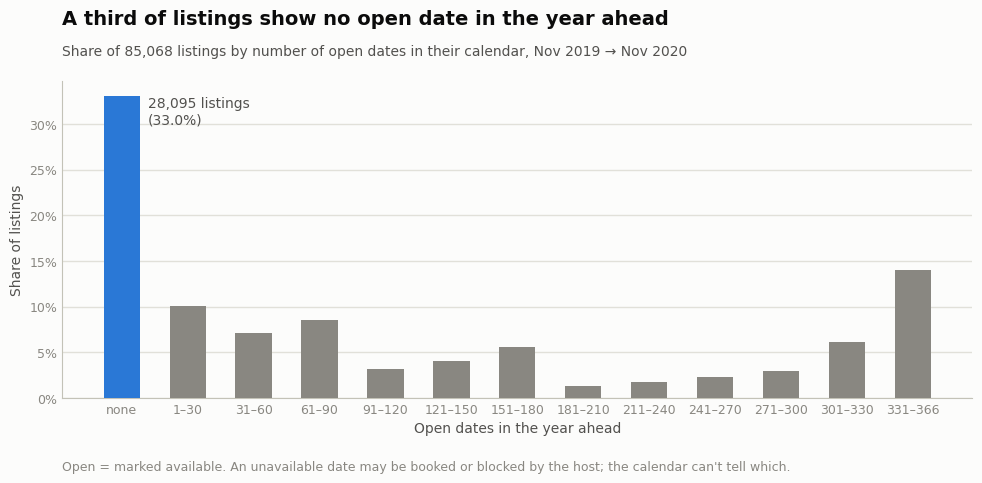

In [4]:
# Figure colours, as in notebook 02 (light background)
SURF, INK, INK2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
BLUE = "#2a78d6"

# Group listings into 30-day bands of open dates; "none" is its own band
edges = [-1, 0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330, 366]
labels = ["none"] + [f"{lo + 1}–{hi}" for lo, hi in zip(edges[1:-1], edges[2:])]
band = pd.cut(per_listing["n_available"], bins=edges, labels=labels)
share = band.value_counts(normalize=True, sort=False) * 100
print(pd.DataFrame({"listings": band.value_counts(sort=False), "share %": share.round(1)}))

fig, ax = plt.subplots(figsize=(10, 4.8), facecolor=SURF)
ax.set_facecolor(SURF)
x = range(len(share))
ax.bar(x, share.values, width=0.55, color=[BLUE] + [MUTED] * (len(share) - 1), zorder=3)
ax.text(0.4, share.iloc[0], f"{n_none:,} listings\n({share.iloc[0]:.1f}%)",
        va="top", ha="left", color=INK2, fontsize=10)

ax.set_xticks(list(x), labels, fontsize=9)
ax.yaxis.set_major_formatter("{x:.0f}%")
ax.set_xlabel("Open dates in the year ahead", color=INK2, fontsize=10)
ax.set_ylabel("Share of listings", color=INK2, fontsize=10)
ax.grid(axis="y", color=GRID, linewidth=1, zorder=0)
for side in ["top", "right"]:
    ax.spines[side].set_visible(False)
for side in ["left", "bottom"]:
    ax.spines[side].set_color(AXIS)
ax.tick_params(colors=MUTED, length=0, labelsize=9)

fig.suptitle("A third of listings show no open date in the year ahead",
             x=0.07, ha="left", color=INK, fontsize=14, fontweight="bold")
fig.text(0.07, 0.885, f"Share of {len(per_listing):,} listings by number of open dates in their calendar, Nov 2019 → Nov 2020",
         ha="left", color=INK2, fontsize=10)
fig.text(0.07, 0.02, "Open = marked available. An unavailable date may be booked or blocked by the host; the calendar can't tell which.",
         ha="left", color=MUTED, fontsize=9)
fig.subplots_adjust(left=0.07, right=0.98, top=0.83, bottom=0.17)
plt.show()


In [5]:
legs = is_active(listings, return_components=True)
legs["never_reviewed"] = listings["number_of_reviews"].eq(0)
legs.index = listings["id"]

table = pd.crosstab(legs["available"], legs["recent_review"], margins=True, margins_name="all")
table = table.rename(index={True: "open on 1+ dates", False: "no open date"},
                     columns={True: "reviewed", False: "not reviewed"})
print("Rows: availability (listings file). Columns: reviewed in the 12 months before the scrape.")
print(table, "\n")

calendar_only = (~legs["available"] & legs["recent_review"]).sum()
reviews_only = (legs["available"] & ~legs["recent_review"]).sum()
never = (legs["available"] & ~legs["recent_review"] & legs["never_reviewed"]).sum()
print(f"Availability alone would call {calendar_only:,} recently reviewed listings dormant")
print(f"Recency alone would drop {reviews_only:,} listings open for booking ({never:,} of them never reviewed)")
print(f"Active (either signal): {legs['active'].sum():,} of {len(legs):,} ({legs['active'].mean():.1%}); "
      f"dormant: {(~legs['active']).sum():,}")


Rows: availability (listings file). Columns: reviewed in the 12 months before the scrape.
recent_review     not reviewed  reviewed    all
available                                      
no open date             19494      8989  28483
open on 1+ dates         15523     41062  56585
all                      35017     50051  85068 

Availability alone would call 8,989 recently reviewed listings dormant
Recency alone would drop 15,523 listings open for booking (11,551 of them never reviewed)
Active (either signal): 65,574 of 85,068 (77.1%); dormant: 19,494


In [6]:
file_days = listings.set_index("id")["availability_365"]
same = file_days.eq(per_listing["n_available"])
fewer = file_days.lt(per_listing["n_available"])
print(f"Open dates, listings file vs calendar: the same for {same.sum():,} listings ({same.mean():.1%}); "
      f"the file shows fewer for {fewer.sum():,} ({(fewer & file_days.eq(0)).sum():,} of them none), "
      f"more for {file_days.gt(per_listing['n_available']).sum():,}\n")

days = per_listing[["first_date", "no_open_date"]].join(legs[["recent_review", "active"]])
by_day = days.groupby("first_date").agg(
    listings=("no_open_date", "size"),
    no_open_date=("no_open_date", "mean"),
    reviewed=("recent_review", "mean"),
    active=("active", "mean"),
)
by_day[["no_open_date", "reviewed", "active"]] *= 100
print("By scrape day (% of that day's listings):")
print(by_day.round(1))


Open dates, listings file vs calendar: the same for 84,679 listings (99.5%); the file shows fewer for 389 (388 of them none), more for 0

By scrape day (% of that day's listings):
            listings  no_open_date  reviewed  active
first_date                                          
2019-11-05     26235          90.4      36.9    39.4
2019-11-06     58833           7.4      68.6    93.9


**What section 2 shows**

1. **A third of listings show no open date** in the year ahead: 28,095, or 33.0%. The rest spread across the year, from a few open dates to 14% open almost every day. *observed*
2. **No open date doesn't mean out of the market.** 8,989 listings whose listings-file availability shows no open date (the field `is_active` reads) were reviewed in the past 12 months, so they had guests recently. Availability alone would call them dormant.
3. **Recent reviews alone miss live listings.** 15,523 listings open for booking had no review in the past year, and 11,551 of them have never been reviewed.
4. **So the study uses either signal.** `is_active` gives 65,574 active listings (77.1%) and 19,494 dormant ones: no open date *and* no review in the past year. *derived (rule-based)*
5. **Two checks:**
   * The listings file's availability field, which `is_active` reads, matches the calendar for 99.5% of listings. Where it doesn't, it shows fewer open dates, so the rule errs toward calling listings dormant.
   * The 5 Nov scrape caught mostly dormant listings: 90% had no open date and 37% had a recent review, against 7% and 69% for 6 Nov. Reviews are independent of the calendar, so this is a real difference between the two days' listings. Why the scraper split them this way isn't documented.

## Where are the dormant listings?

The same rule, by borough: the share of each borough's listings that are dormant.

                        listings  dormant %
neighbourhood_cleansed                     
Hackney                     6276       34.1
Haringey                    2197       30.3
Islington                   5108       30.0
Wandsworth                  4272       28.7
Lewisham                    2296       27.5
Havering                     255       13.3
Barking and Dagenham         372       12.9
City of London               465       12.7
Bexley                       269       12.6
Hillingdon                   668        9.7


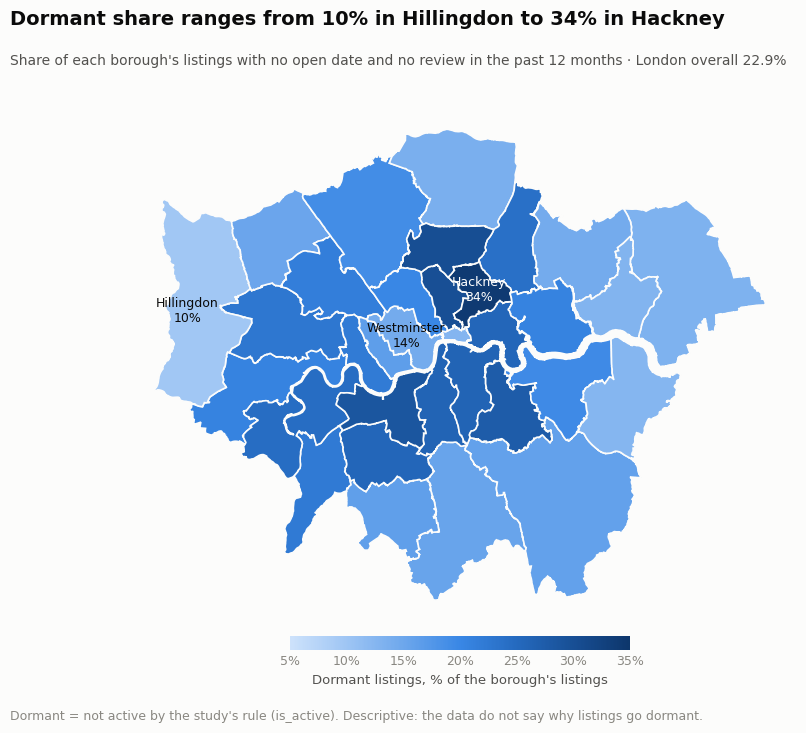

In [7]:
borough = listings.set_index("id")["neighbourhood_cleansed"]
by_borough = pd.DataFrame({"listings": borough.value_counts(),
                           "dormant %": (~legs["active"]).groupby(borough).mean() * 100})
by_borough = by_borough.sort_values("dormant %", ascending=False).round(1)
print(pd.concat([by_borough.head(5), by_borough.tail(5)]))

with open(DATA_DIR / "neighbourhoods.geojson") as f:
    features = json.load(f)["features"]

# sequential blue ramp (light = few dormant, dark = many)
ramp = LinearSegmentedColormap.from_list("blues", ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])
norm = Normalize(vmin=5, vmax=35)

fig = plt.figure(figsize=(10, 7.4), facecolor=SURF)
ax = fig.add_axes([0.03, 0.15, 0.94, 0.70], facecolor=SURF)
for feat in features:
    name = feat["properties"]["neighbourhood"]
    colour = ramp(norm(by_borough.loc[name, "dormant %"]))
    for polygon in feat["geometry"]["coordinates"]:
        lon, lat = zip(*polygon[0])                  # outer ring of each piece
        ax.fill(lon, lat, facecolor=colour, edgecolor=SURF, linewidth=1.2)

for name in ["Hackney", "Westminster", "Hillingdon"]:
    feat = next(f for f in features if f["properties"]["neighbourhood"] == name)
    ring = max(feat["geometry"]["coordinates"], key=lambda p: len(p[0]))[0]
    lon = sum(p[0] for p in ring) / len(ring); lat = sum(p[1] for p in ring) / len(ring)
    value = by_borough.loc[name, "dormant %"]
    ax.text(lon, lat, f"{name}\n{value:.0f}%", ha="center", va="center", fontsize=9,
            color="white" if value > 25 else INK)

ax.set_aspect(1 / math.cos(math.radians(51.5)))   # degrees of longitude are shorter at London's latitude
ax.axis("off")
cax = fig.add_axes([0.33, 0.115, 0.34, 0.018])
bar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=ramp), cax=cax, orientation="horizontal")
bar.set_label("Dormant listings, % of the borough's listings", color=INK2, fontsize=9.5)
bar.ax.xaxis.set_major_formatter("{x:.0f}%")
bar.ax.tick_params(colors=MUTED, length=0, labelsize=9)
bar.outline.set_visible(False)

fig.suptitle("Dormant share ranges from 10% in Hillingdon to 34% in Hackney",
             x=0.05, ha="left", color=INK, fontsize=14, fontweight="bold")
fig.text(0.05, 0.905, f"Share of each borough's listings with no open date and no review in the past 12 months · "
         f"London overall {(~legs['active']).mean():.1%}", ha="left", color=INK2, fontsize=10)
fig.text(0.05, 0.02, "Dormant = not active by the study's rule (is_active). Descriptive: the data do not say why listings go dormant.",
         ha="left", color=MUTED, fontsize=9)
plt.show()


- *The range*: the dormant share runs from 9.7% in Hillingdon to 34.1% in Hackney; London overall is 22.9%.
- *The pattern*: it is highest in the inner boroughs around the centre (Hackney, Haringey, Islington, Wandsworth, Lewisham) and lower in Westminster (14%), the City and the outer boroughs.
- *Why it matters*: [notebook 02](02-pricing-behavior.ipynb) keeps only active listings, so it drops about a third of Hackney's listings but only a tenth of Hillingdon's.
- *Label and caveat*: derived (rule-based). The map describes where dormant listings are; the data does not say why.


## 3. Unavailability spells

- *A Spell* -- a run of consecutive unavailable dates in one listing's calendar. A listing closed on 1–10 December and again on 3–5 January has two spells.
- *What a spell could represent*: a guest's stay, several stays back to back, dates the host blocked, or dates the host hasn't opened for booking yet. The calendar marks all of them the same way.
- *Open-ended spells*: a spell that runs to the listing's last calendar date is cut off by the end of the data, so its real length is unknown.
- *Question*: how many spells are open-ended, and do they look like bookings?


In [8]:
days = cal.sort_values(["listing_id", "date"], ignore_index=True)
new_listing = days["listing_id"].ne(days["listing_id"].shift())
assert (days["date"].diff().dt.days.eq(1) | new_listing).all(), "dates are not consecutive"

closed = ~days["available"]
starts = closed & (new_listing | days["available"].shift(fill_value=True))
spell_id = starts.cumsum()

spells = (days[closed].groupby(spell_id[closed])
          .agg(listing_id=("listing_id", "first"), start=("date", "min"), end=("date", "max"), length=("date", "size")))
spells = spells.join(per_listing[["first_date", "last_date"]], on="listing_id")
spells["open_ended"] = spells["end"].eq(spells["last_date"])
spells["whole_calendar"] = spells["open_ended"] & spells["start"].eq(spells["first_date"])
spells["days_ahead"] = (spells["start"] - spells["first_date"]).dt.days
del days

later = spells[spells["open_ended"] & ~spells["whole_calendar"]]
at_horizon = later["days_ahead"].isin([90, 180, 270])
print(f"Unavailability spells: {len(spells):,} in {spells['listing_id'].nunique():,} listings")
print(f"Open-ended (run to the listing's last date): {spells['open_ended'].sum():,} ({spells['open_ended'].mean():.1%})")
print(f"  cover the whole calendar:   {spells['whole_calendar'].sum():,}")
print(f"  start later:                {len(later):,}")
print(f"    exactly 90 / 180 / 270 days after the first date: {at_horizon.sum():,} "
      f"({later['days_ahead'].eq(90).sum():,} / {later['days_ahead'].eq(180).sum():,} / {later['days_ahead'].eq(270).sum():,})")
print(f"Closed (end before the calendar does): {(~spells['open_ended']).sum():,}")
explained = spells["whole_calendar"].sum() + at_horizon.sum()
print(f"Open-ended spells that cover the whole calendar or start at 90 / 180 / 270 days: "
      f"{explained:,} ({explained / spells['open_ended'].sum():.1%})")


Unavailability spells: 290,489 in 82,383 listings
Open-ended (run to the listing's last date): 61,323 (21.1%)
  cover the whole calendar:   28,095
  start later:                33,228
    exactly 90 / 180 / 270 days after the first date: 18,226 (8,807 / 7,937 / 1,482)
Closed (end before the calendar does): 229,166
Open-ended spells that cover the whole calendar or start at 90 / 180 / 270 days: 46,321 (75.5%)


Open-ended spells starting after the first date: 33,228
  exactly on day 90 / 180 / 270: 18,226 (54.9%)
  largest 10-day total without them: 2,230 (days 51-60)


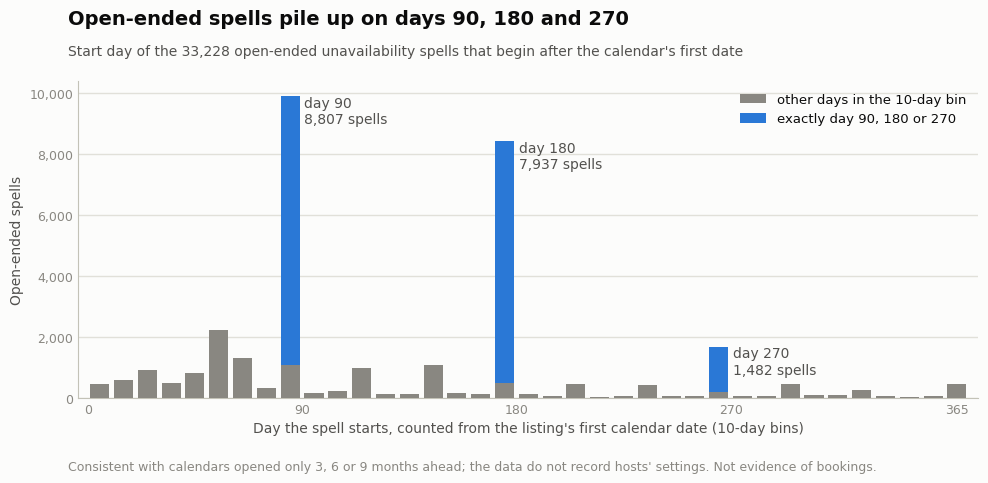

In [9]:
HORIZONS = [90, 180, 270]
on_horizon = later["days_ahead"].isin(HORIZONS)
bins = list(range(0, 371, 10))                       # 1-10, 11-20, ..., 361-370
ten_day = pd.cut(later["days_ahead"], bins=bins, labels=bins[1:])
exact = ten_day[on_horizon].value_counts(sort=False)
other = ten_day[~on_horizon].value_counts(sort=False)
print(f"Open-ended spells starting after the first date: {len(later):,}")
print(f"  exactly on day 90 / 180 / 270: {on_horizon.sum():,} ({on_horizon.mean():.1%})")
print(f"  largest 10-day total without them: {other.max():,} (days {other.idxmax() - 9}-{other.idxmax()})")

x = [b - 5 for b in bins[1:]]                        # centre of each 10-day bin
fig, ax = plt.subplots(figsize=(10, 4.8), facecolor=SURF)
ax.set_facecolor(SURF)
ax.bar(x, other.values, width=8, color=MUTED, zorder=3, label="other days in the 10-day bin")
ax.bar(x, exact.values, width=8, bottom=other.values, color=BLUE, zorder=3, label="exactly day 90, 180 or 270")
for h in HORIZONS:
    ax.text(h + 1, other[h] + exact[h], f"day {h}\n{exact[h]:,} spells", va="top", ha="left", color=INK2, fontsize=10)

ax.set_xlim(-4, 374)
ax.set_xticks([0, 90, 180, 270, 365])
ax.yaxis.set_major_formatter("{x:,.0f}")
ax.set_xlabel("Day the spell starts, counted from the listing's first calendar date (10-day bins)", color=INK2, fontsize=10)
ax.set_ylabel("Open-ended spells", color=INK2, fontsize=10)
ax.grid(axis="y", color=GRID, linewidth=1, zorder=0)
for side in ["top", "right"]:
    ax.spines[side].set_visible(False)
for side in ["left", "bottom"]:
    ax.spines[side].set_color(AXIS)
ax.tick_params(colors=MUTED, length=0, labelsize=9)
ax.legend(loc="upper right", frameon=False, fontsize=9.5, labelcolor=INK)

fig.suptitle("Open-ended spells pile up on days 90, 180 and 270",
             x=0.07, ha="left", color=INK, fontsize=14, fontweight="bold")
fig.text(0.07, 0.885, f"Start day of the {len(later):,} open-ended unavailability spells that begin after the calendar's first date",
         ha="left", color=INK2, fontsize=10)
fig.text(0.07, 0.02, "Consistent with calendars opened only 3, 6 or 9 months ahead; the data do not record hosts' settings. "
         "Not evidence of bookings.", ha="left", color=MUTED, fontsize=9)
fig.subplots_adjust(left=0.08, right=0.98, top=0.83, bottom=0.17)
plt.show()


- The calendar has 290,489 unavailability spells, and 61,323 of them (21.1%) are open-ended. They run to the listing's last calendar date, so their real length is unknown.
- *What the open-ended ones look like*: 28,095 cover the whole calendar, and 18,226 start exactly 90, 180 or 270 days after the listing's first date. Together that is 46,321, or 75.5% of open-ended spells.
-  This pattern is consistent with calendars that either are shut, or opened only 3, 6 or 9 months ahead. Bookings would not pile up on the same single day across thousands of listings. The data do not record hosts' settings, so this is an interpretation, not an observation.
- The other 229,166 spells are closed. Each could be one stay, several stays back to back, or dates the host blocked. The calendar cannot say which, so this notebook reports no stay lengths and no booking counts.
- *Consequence*: an unavailable date is not a booked date.

## 4. A cross-check: clustering calendar shapes

Section 3 found the 3-month and 6-month calendars with an exact rule. Here a different method looks for them without being told what to find.

- **What goes in:** for each listing with at least one open date, the share of open dates in each 30-day block of the year ahead, 12 numbers per listing.
- **The method:** k-means sorts listings into groups with similar calendars.
- **The label:** descriptive only. The groups are a picture of the data; nothing in the study uses them.


In [10]:
day = (cal["date"] - cal["listing_id"].map(per_listing["first_date"])).dt.days
block = ((day // 30).clip(upper=11) + 1).rename("block")       # 30-day blocks 1-12; block 12 also takes days 360-365
shape = cal["available"].groupby([cal["listing_id"], block]).mean().unstack()
shape = shape[~per_listing["no_open_date"]]                     # listings with at least one open date
del day, block
print(f"Listings clustered: {len(shape):,}, each described by {shape.shape[1]} numbers "
      f"(share of open dates in each 30-day block)\n")

print("Silhouette score by number of groups (10,000-listing sample; higher = better separated):")
for k in range(2, 7):
    labels = KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(shape)
    print(f"  k = {k}: {silhouette_score(shape, labels, sample_size=10_000, random_state=42):.2f}")

km = KMeans(n_clusters=4, n_init=10, random_state=42).fit(shape)
centres = pd.DataFrame(km.cluster_centers_, columns=shape.columns)
NAMES = ["open all year", "open about 6 months", "open about 3 months", "mostly closed"]
most_open_first = centres.mean(axis=1).sort_values(ascending=False).index
group = pd.Series(km.labels_, index=shape.index).map(dict(zip(most_open_first, NAMES)))
centres = centres.loc[most_open_first].set_axis(NAMES)

closes_on = later.set_index("listing_id")["days_ahead"].reindex(shape.index)    # missing = open to its last date
check = pd.DataFrame({
    "listings": group.value_counts(),
    "closes day 90 %": closes_on.eq(90).groupby(group).mean() * 100,
    "closes day 180 %": closes_on.eq(180).groupby(group).mean() * 100,
    "closes day 270 %": closes_on.eq(270).groupby(group).mean() * 100,
    "open to the end %": closes_on.isna().groupby(group).mean() * 100,
}).reindex(NAMES).round(1)
print("\nFour groups (k = 4), checked against the open-ended spells of section 3:")
print(check.to_string())


Listings clustered: 56,973, each described by 12 numbers (share of open dates in each 30-day block)

Silhouette score by number of groups (10,000-listing sample; higher = better separated):


  k = 2: 0.54


  k = 3: 0.50


  k = 4: 0.46


  k = 5: 0.43


  k = 6: 0.42

Four groups (k = 4), checked against the open-ended spells of section 3:
                     listings  closes day 90 %  closes day 180 %  closes day 270 %  open to the end %
open all year           22586              0.0               0.0               0.0               96.0
open about 6 months     10982              0.0              62.5              11.2                2.6
open about 3 months     10236             72.5               1.1               0.1                1.0
mostly closed           13169             10.5               7.3               1.8               12.7


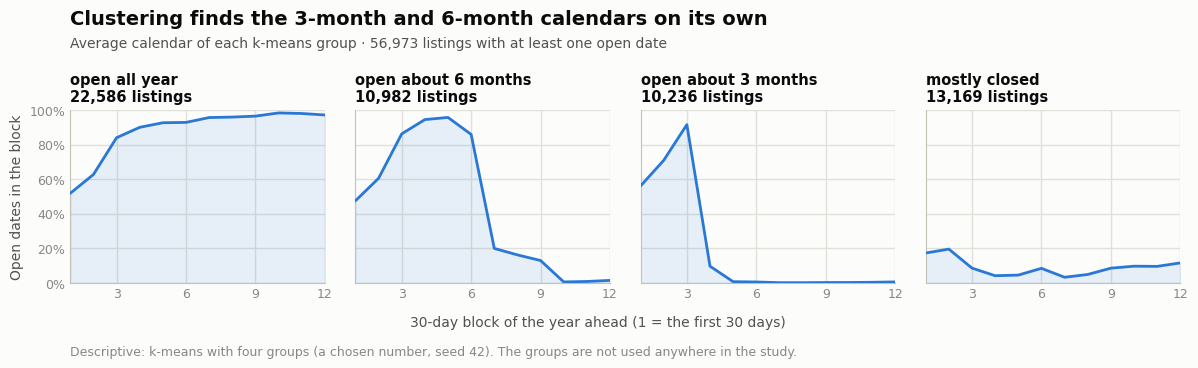

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3.6), sharey=True, facecolor=SURF)
for ax, name in zip(axes, NAMES):
    ax.set_facecolor(SURF)
    y = centres.loc[name] * 100
    ax.fill_between(y.index, y.values, color=BLUE, alpha=0.10, zorder=2)
    ax.plot(y.index, y.values, color=BLUE, linewidth=2, solid_capstyle="round", solid_joinstyle="round", zorder=3)
    ax.set_title(f"{name}\n{check.loc[name, 'listings']:,} listings", loc="left", color=INK, fontsize=10.5, fontweight="bold")
    ax.set_xticks([3, 6, 9, 12])
    ax.set_xlim(1, 12)
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter("{x:.0f}%")
    ax.grid(color=GRID, linewidth=1, zorder=0)
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)
    for side in ["left", "bottom"]:
        ax.spines[side].set_color(AXIS)
    ax.tick_params(colors=MUTED, length=0, labelsize=9)
axes[0].set_ylabel("Open dates in the block", color=INK2, fontsize=10)
fig.supxlabel("30-day block of the year ahead (1 = the first 30 days)", color=INK2, fontsize=10, y=0.09)

fig.suptitle("Clustering finds the 3-month and 6-month calendars on its own",
             x=0.06, ha="left", color=INK, fontsize=14, fontweight="bold")
fig.text(0.06, 0.875, f"Average calendar of each k-means group · {len(shape):,} listings with at least one open date",
         ha="left", color=INK2, fontsize=10)
fig.text(0.06, 0.02, "Descriptive: k-means with four groups (a chosen number, seed 42). The groups are not used anywhere in the study.",
         ha="left", color=MUTED, fontsize=9)
fig.subplots_adjust(left=0.06, right=0.985, top=0.70, bottom=0.22, wspace=0.12)
plt.show()


- **Four calendar shapes:** k-means with four groups splits the 56,973 listings that have at least one open date into calendars open all year (22,586), open about 6 months (10,982), open about 3 months (10,236) and mostly closed (13,169).
- **It agrees with section 3:** 72.5% of the "3 months" group close exactly on day 90, and the "6 months" group closes on day 180 (62.5%) or day 270 (11.2%). The clustering never saw those days; it found the same pattern from the calendar shapes alone.
- **The choices behind it:** four groups is a choice. The silhouette score is highest with two groups (0.54 against 0.46), but two groups only separate mostly open from mostly closed calendars. Seed 42.
- **Label:** *descriptive*. The groups are a picture of the calendars; nothing in the study uses them.


## What this means
- *Active listings*: [notebook 02](02-pricing-behavior.ipynb) studies the 65,574 active listings, those with an open date or a review in the past 12 months. Neither signal alone is enough (section 2).
- *No occupancy or revenue*: unavailable dates mix bookings, host blocks and calendars not yet opened (section 3), so the study makes no claims about bookings, occupancy or revenue. It studies posted prices, and repeats its main results on available dates only as a check.
- *Per-listing windows*: calendars start on two different days, and 274 run a day longer (section 1), so every window is set by each listing's own first and last dates.